# Comparaison Embeddings × Classifieurs — Sentiment Archelec
Benchmark de plusieurs approches sur les **200 mentions annotées** (2 classes : positif / négatif).

- **Embeddings** : TF-IDF unigrams, TF-IDF bigrams, CamemBERT [CLS] frozen, CamemBERT mean-pooling frozen
- **Classifieurs** : Logistic Regression, SVM, Random Forest
- **Évaluation** : 5-fold cross-validation stratifiée → macro F1 + F1 négatif (classe rare)

## 0 — Imports & données

In [2]:
import os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.utils.class_weight import compute_class_weight

ROOT_DIR   = Path(os.getcwd()).parent
INPUT_FILE = ROOT_DIR / "data" / "results" / "output_best_model" / "leaders_mentions.xlsx"
GRAPHS_DIR = ROOT_DIR / "data" / "results" / "output_best_model" / "graphs"
os.makedirs(GRAPHS_DIR, exist_ok=True)

df = pd.read_excel(INPUT_FILE)
df = df[df["sentiment_president"].isin(["positif", "négatif"])].copy()
df["label"] = (df["sentiment_president"] == "positif").astype(int)

X = df["text"].fillna("").tolist()
y = df["label"].tolist()

print(f"Samples : {len(df)}")
print(f"positif : {sum(y)}  |  négatif : {len(y)-sum(y)}")


Samples : 200
positif : 186  |  négatif : 14


## 1 — Méthodes TF-IDF + classifieurs classiques

In [3]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1_macro":   make_scorer(f1_score, average="macro",    zero_division=0),
    "f1_negatif": make_scorer(f1_score, pos_label=0, average="binary", zero_division=0),
    "f1_positif": make_scorer(f1_score, pos_label=1, average="binary", zero_division=0),
}

def run_cv(name, pipeline):
    scores = cross_validate(pipeline, X, y, cv=CV, scoring=scoring, n_jobs=-1)
    return {
        "Méthode":       name,
        "F1 macro":      round(scores["test_f1_macro"].mean(),   3),
        "F1 négatif":    round(scores["test_f1_negatif"].mean(), 3),
        "F1 positif":    round(scores["test_f1_positif"].mean(), 3),
        "F1 macro std":  round(scores["test_f1_macro"].std(),    3),
    }

results = []

# ── TF-IDF unigrams ────────────────────────────────────────────────────────────
tfidf_uni = TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)
tfidf_bi  = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)

classifiers = {
    "LogReg": LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0),
    "SVM":    LinearSVC(class_weight="balanced", max_iter=2000, C=1.0),
    "RF":     RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
}

for clf_name, clf in classifiers.items():
    results.append(run_cv(f"TF-IDF uni + {clf_name}",    Pipeline([("tfidf", tfidf_uni), ("clf", clf)])))
    results.append(run_cv(f"TF-IDF bigram + {clf_name}", Pipeline([("tfidf", tfidf_bi),  ("clf", clf)])))
    print(f"✓ TF-IDF uni & bigram + {clf_name}")

df_tfidf = pd.DataFrame(results)
print()
print(df_tfidf.sort_values("F1 macro", ascending=False).to_string(index=False))


✓ TF-IDF uni & bigram + LogReg
✓ TF-IDF uni & bigram + SVM
✓ TF-IDF uni & bigram + RF

               Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
   TF-IDF uni + LogReg     0.766       0.553       0.979         0.154
TF-IDF bigram + LogReg     0.766       0.553       0.979         0.154
      TF-IDF uni + SVM     0.766       0.553       0.979         0.154
   TF-IDF bigram + SVM     0.766       0.553       0.979         0.154
       TF-IDF uni + RF     0.766       0.553       0.979         0.154
    TF-IDF bigram + RF     0.766       0.553       0.979         0.154


## 2 — CamemBERT frozen embeddings

In [4]:
import torch
from transformers import CamembertTokenizer, CamembertModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model_emb = CamembertModel.from_pretrained("camembert-base").to(device)
model_emb.eval()

def get_embeddings(texts, batch_size=32, pooling="cls"):
    """Extrait les embeddings CamemBERT (frozen). pooling : 'cls' ou 'mean'."""
    all_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc=f"Embed ({pooling})"):
            batch = texts[i:i+batch_size]
            enc = tokenizer(
                batch, truncation=True, padding=True,
                max_length=256, return_tensors="pt"
            ).to(device)
            out = model_emb(**enc)
            if pooling == "cls":
                emb = out.last_hidden_state[:, 0, :]          # [CLS] token
            else:
                mask = enc["attention_mask"].unsqueeze(-1).float()
                emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)  # mean pooling
            all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs)

X_cls  = get_embeddings(X, pooling="cls")
X_mean = get_embeddings(X, pooling="mean")
print(f"Shape CLS  : {X_cls.shape}")
print(f"Shape Mean : {X_mean.shape}")


Device : cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4289.95it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embed (mean): 100%|██████████| 7/7 [00:01<00:00,  3.70it/s]

Shape CLS  : (200, 768)
Shape Mean : (200, 768)


In [5]:
from sklearn.preprocessing import StandardScaler

results_emb = []

for emb_name, X_emb in [("CamemBERT [CLS]", X_cls), ("CamemBERT mean", X_mean)]:
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
        scores = cross_validate(pipe, X_emb, y, cv=CV, scoring=scoring, n_jobs=-1)
        results_emb.append({
            "Méthode":      f"{emb_name} + {clf_name}",
            "F1 macro":     round(scores["test_f1_macro"].mean(),   3),
            "F1 négatif":   round(scores["test_f1_negatif"].mean(), 3),
            "F1 positif":   round(scores["test_f1_positif"].mean(), 3),
            "F1 macro std": round(scores["test_f1_macro"].std(),    3),
        })
        print(f"✓ {emb_name} + {clf_name}")

df_emb = pd.DataFrame(results_emb)
print()
print(df_emb.sort_values("F1 macro", ascending=False).to_string(index=False))


✓ CamemBERT [CLS] + LogReg
✓ CamemBERT [CLS] + SVM
✓ CamemBERT [CLS] + RF
✓ CamemBERT mean + LogReg
✓ CamemBERT mean + SVM
✓ CamemBERT mean + RF

                 Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
     CamemBERT mean + RF     0.766       0.553       0.979         0.154
    CamemBERT [CLS] + RF     0.766       0.553       0.979         0.154
   CamemBERT [CLS] + SVM     0.726       0.498       0.953         0.101
 CamemBERT mean + LogReg     0.722       0.473       0.971         0.141
CamemBERT [CLS] + LogReg     0.721       0.474       0.968         0.146
    CamemBERT mean + SVM     0.720       0.486       0.954         0.081


## 3 — Tableau comparatif complet

In [6]:
# Ajouter CamemBERT fine-tuné (résultat du notebook principal)
df_finetuned = pd.DataFrame([{
    "Méthode":      "CamemBERT fine-tuné",
    "F1 macro":     0.47,
    "F1 négatif":   0.00,
    "F1 positif":   0.95,
    "F1 macro std": float("nan"),
}])

df_all = pd.concat([df_tfidf, df_emb, df_finetuned], ignore_index=True)
df_all = df_all.sort_values("F1 macro", ascending=False).reset_index(drop=True)

print("=" * 70)
print("Comparaison complète — 5-fold CV stratifiée (sauf fine-tuné)")
print("=" * 70)
print(df_all.to_string(index=False))


Comparaison complète — 5-fold CV stratifiée (sauf fine-tuné)
                 Méthode  F1 macro  F1 négatif  F1 positif  F1 macro std
     TF-IDF uni + LogReg     0.766       0.553       0.979         0.154
  TF-IDF bigram + LogReg     0.766       0.553       0.979         0.154
        TF-IDF uni + SVM     0.766       0.553       0.979         0.154
     TF-IDF bigram + SVM     0.766       0.553       0.979         0.154
         TF-IDF uni + RF     0.766       0.553       0.979         0.154
      TF-IDF bigram + RF     0.766       0.553       0.979         0.154
    CamemBERT [CLS] + RF     0.766       0.553       0.979         0.154
     CamemBERT mean + RF     0.766       0.553       0.979         0.154
   CamemBERT [CLS] + SVM     0.726       0.498       0.953         0.101
 CamemBERT mean + LogReg     0.722       0.473       0.971         0.141
CamemBERT [CLS] + LogReg     0.721       0.474       0.968         0.146
    CamemBERT mean + SVM     0.720       0.486       0.954     

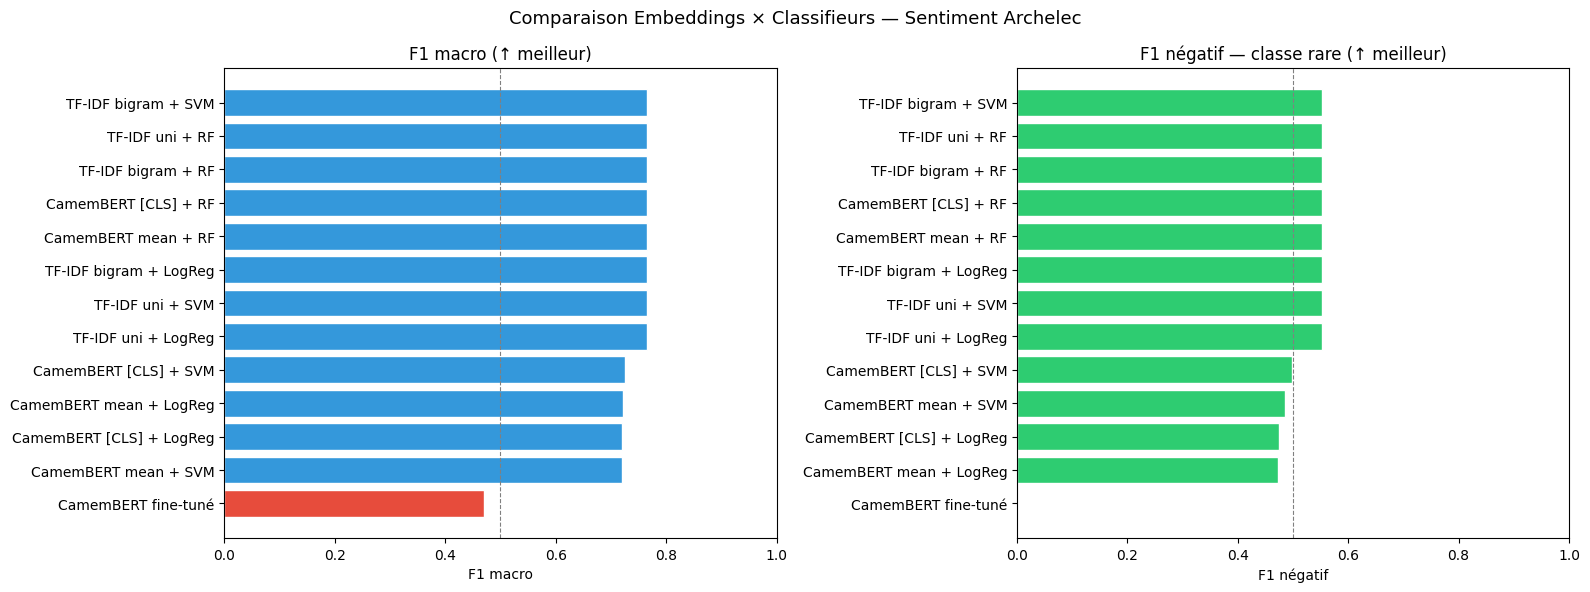

Graphique sauvegardé : /home/onyxia/work/Named_Entity_Extraction_Archelec_Corpus/projet_archelec/data/results/output_best_model/graphs/comparison_methods.png


In [7]:
# ── Graphique comparatif ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F1 macro
df_plot = df_all.sort_values("F1 macro")
colors  = ["#e74c3c" if "fine-tuné" in m else "#3498db" for m in df_plot["Méthode"]]
axes[0].barh(df_plot["Méthode"], df_plot["F1 macro"], color=colors, edgecolor="white")
axes[0].axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("F1 macro (↑ meilleur)")
axes[0].set_xlabel("F1 macro")
axes[0].set_xlim(0, 1)

# F1 négatif (classe rare)
df_plot2 = df_all.sort_values("F1 négatif")
colors2  = ["#e74c3c" if "fine-tuné" in m else "#2ecc71" for m in df_plot2["Méthode"]]
axes[1].barh(df_plot2["Méthode"], df_plot2["F1 négatif"], color=colors2, edgecolor="white")
axes[1].axvline(x=0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("F1 négatif — classe rare (↑ meilleur)")
axes[1].set_xlabel("F1 négatif")
axes[1].set_xlim(0, 1)

plt.suptitle("Comparaison Embeddings × Classifieurs — Sentiment Archelec", fontsize=13)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "comparison_methods.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Graphique sauvegardé : {GRAPHS_DIR / 'comparison_methods.png'}")


In [8]:
# ── Meilleure méthode ─────────────────────────────────────────────────────────
best = df_all.iloc[0]
print(f"Meilleure méthode (F1 macro) : {best['Méthode']}")
print(f"  F1 macro   : {best['F1 macro']}")
print(f"  F1 négatif : {best['F1 négatif']}")
print(f"  F1 positif : {best['F1 positif']}")

df_all.to_excel(
    ROOT_DIR / "data" / "results" / "output_best_model" / "comparison_methods.xlsx",
    index=False
)
print("\nTableau sauvegardé : comparison_methods.xlsx")


Meilleure méthode (F1 macro) : TF-IDF uni + LogReg
  F1 macro   : 0.766
  F1 négatif : 0.553
  F1 positif : 0.979

Tableau sauvegardé : comparison_methods.xlsx


## 4 — SMOTE : sur-échantillonnage de la classe minoritaire
Crée des exemples négatifs synthétiques dans l'espace des features (TF-IDF et CamemBERT embeddings).

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

results_smote = []

# SMOTE ne fonctionne que si k_neighbors < n_minority → k=2 pour 14 négatifs
smote = SMOTE(random_state=42, k_neighbors=2)

configs = [
    ("TF-IDF uni + SMOTE + LogReg",
     ImbPipeline([
         ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)),
         ("smote", smote),
         ("clf",   LogisticRegression(max_iter=1000, C=1.0)),
     ])),
    ("TF-IDF uni + SMOTE + SVM",
     ImbPipeline([
         ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)),
         ("smote", smote),
         ("clf",   LinearSVC(max_iter=2000, C=1.0)),
     ])),
    ("CamemBERT CLS + SMOTE + LogReg",
     ImbPipeline([
         ("scaler", StandardScaler()),
         ("smote",  smote),
         ("clf",    LogisticRegression(max_iter=1000, C=1.0)),
     ])),
    ("CamemBERT CLS + SMOTE + SVM",
     ImbPipeline([
         ("scaler", StandardScaler()),
         ("smote",  smote),
         ("clf",    LinearSVC(max_iter=2000, C=1.0)),
     ])),
]

X_arr = np.array(X)  # pour les pipelines TF-IDF

for name, pipe in configs:
    X_in = X_arr if "TF-IDF" in name else X_cls
    scores = cross_validate(pipe, X_in, y, cv=CV, scoring=scoring, n_jobs=1)
    results_smote.append({
        "Méthode":      name,
        "F1 macro":     round(scores["test_f1_macro"].mean(),   3),
        "F1 négatif":   round(scores["test_f1_negatif"].mean(), 3),
        "F1 positif":   round(scores["test_f1_positif"].mean(), 3),
        "F1 macro std": round(scores["test_f1_macro"].std(),    3),
    })
    print(f"✓ {name}")

df_smote = pd.DataFrame(results_smote)
print()
print(df_smote.sort_values("F1 macro", ascending=False).to_string(index=False))


## 5 — Threshold tuning
Par défaut, LogReg prédit positif si `proba > 0.5`. Baisser ce seuil permet de capturer plus de négatifs (meilleur recall) au prix d'un peu de précision.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

y_arr = np.array(y)
results_thresh = []

thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1,1), sublinear_tf=True)
logreg    = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0)

for thresh in thresholds:
    f1_macros, f1_negs = [], []
    for train_idx, test_idx in CV.split(X, y_arr):
        X_tr = [X[i] for i in train_idx]
        X_te = [X[i] for i in test_idx]
        y_tr, y_te = y_arr[train_idx], y_arr[test_idx]

        X_tr_tfidf = tfidf_vec.fit_transform(X_tr)
        X_te_tfidf = tfidf_vec.transform(X_te)
        logreg.fit(X_tr_tfidf, y_tr)

        # Appliquer threshold custom
        probas = logreg.predict_proba(X_te_tfidf)[:, 1]
        preds  = (probas >= thresh).astype(int)

        f1_macros.append(f1_score(y_te, preds, average="macro",    zero_division=0))
        f1_negs.append(  f1_score(y_te, preds, pos_label=0,
                                  average="binary", zero_division=0))

    results_thresh.append({
        "Threshold":    thresh,
        "F1 macro":     round(np.mean(f1_macros), 3),
        "F1 négatif":   round(np.mean(f1_negs),   3),
        "F1 macro std": round(np.std(f1_macros),   3),
    })

df_thresh = pd.DataFrame(results_thresh)
print(df_thresh.to_string(index=False))

best_thresh = df_thresh.loc[df_thresh["F1 macro"].idxmax()]
print(f"\nMeilleur threshold : {best_thresh['Threshold']}  "
      f"→ F1 macro={best_thresh['F1 macro']}  F1 négatif={best_thresh['F1 négatif']}")

# Courbe F1 macro vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_thresh["Threshold"], df_thresh["F1 macro"],   marker="o", label="F1 macro")
ax.plot(df_thresh["Threshold"], df_thresh["F1 négatif"], marker="s", label="F1 négatif")
ax.axvline(x=best_thresh["Threshold"], color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Threshold (seuil de décision positif)")
ax.set_ylabel("F1")
ax.set_title("Threshold tuning — TF-IDF + LogReg")
ax.legend()
plt.tight_layout()
plt.savefig(GRAPHS_DIR / "threshold_tuning.png", dpi=150)
plt.show()


## 6 — Focal Loss + CamemBERT fine-tuning
La Focal Loss réduit le poids des exemples faciles (positifs bien classés) et concentre l'apprentissage sur les exemples difficiles (négatifs).

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    CamembertTokenizer, CamembertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score as sk_f1

ROOT_DIR       = Path(os.getcwd()).parent
MODEL_SAVE_DIR = ROOT_DIR / "data" / "results" / "sentiment_model_focal"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# ── Focal Loss ────────────────────────────────────────────────────────────────
def focal_loss(logits, labels, alpha=0.25, gamma=2.0):
    """alpha : poids de la classe rare (négatif=0), gamma : focus sur les cas difficiles."""
    ce   = F.cross_entropy(logits, labels, reduction="none")
    pt   = torch.exp(-ce)
    # alpha par classe : alpha pour négatif, (1-alpha) pour positif
    alpha_t = torch.where(labels == 0,
                          torch.tensor(alpha,     device=logits.device),
                          torch.tensor(1 - alpha, device=logits.device))
    return (alpha_t * (1 - pt) ** gamma * ce).mean()

# ── Dataset ───────────────────────────────────────────────────────────────────
MAX_LENGTH = 256
tok = CamembertTokenizer.from_pretrained("camembert-base")

class SentimentDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.enc    = tok(texts, truncation=True, padding="max_length",
                         max_length=MAX_LENGTH, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.labels[i]
        return item

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

train_ds = SentimentDataset(X_train, y_train)
val_ds   = SentimentDataset(X_val,   y_val)
test_ds  = SentimentDataset(X_test,  y_test)

# ── Trainer avec Focal Loss ───────────────────────────────────────────────────
LABEL_MAP = {"négatif": 0, "positif": 1}
ID2LABEL  = {0: "négatif", 1: "positif"}

model_focal = CamembertForSequenceClassification.from_pretrained(
    "camembert-base", num_labels=2, id2label=ID2LABEL, label2id=LABEL_MAP)

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = focal_loss(outputs.logits, labels, alpha=0.75, gamma=2.0)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    preds  = np.argmax(eval_pred.predictions, axis=-1)
    labels = eval_pred.label_ids
    return {
        "f1_macro":   float(sk_f1(labels, preds, average="macro",  zero_division=0)),
        "f1_negatif": float(sk_f1(labels, preds, pos_label=0,
                                  average="binary", zero_division=0)),
    }

use_gpu = torch.cuda.is_available()
args = TrainingArguments(
    output_dir=str(MODEL_SAVE_DIR),
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=10,
    report_to="none",
    fp16=use_gpu,
    warmup_ratio=0.1,
)

trainer_focal = FocalTrainer(
    model=model_focal, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print(f"Device : {'GPU' if use_gpu else 'CPU'}")
trainer_focal.train()


In [ ]:
from sklearn.metrics import classification_report

pred_out      = trainer_focal.predict(test_ds)
y_pred_focal  = np.argmax(pred_out.predictions, axis=-1)

print("Classification Report — Focal Loss (test set)")
print(classification_report(y_test, y_pred_focal, target_names=["négatif", "positif"], zero_division=0))

f1_focal_macro = sk_f1(y_test, y_pred_focal, average="macro",  zero_division=0)
f1_focal_neg   = sk_f1(y_test, y_pred_focal, pos_label=0, average="binary", zero_division=0)
print(f"F1 macro   : {f1_focal_macro:.3f}")
print(f"F1 négatif : {f1_focal_neg:.3f}")


## 7 — Tableau final toutes méthodes

In [ ]:
best_thresh_row = df_thresh.loc[df_thresh["F1 macro"].idxmax()]

df_final = pd.concat([
    df_all,
    df_smote.rename(columns={}),
    pd.DataFrame([{
        "Méthode":      f"TF-IDF + LogReg (thresh={best_thresh_row['Threshold']})",
        "F1 macro":     best_thresh_row["F1 macro"],
        "F1 négatif":   best_thresh_row["F1 négatif"],
        "F1 positif":   float("nan"),
        "F1 macro std": best_thresh_row["F1 macro std"],
    }]),
    pd.DataFrame([{
        "Méthode":      "CamemBERT Focal Loss",
        "F1 macro":     round(f1_focal_macro, 3),
        "F1 négatif":   round(f1_focal_neg,   3),
        "F1 positif":   float("nan"),
        "F1 macro std": float("nan"),
    }]),
], ignore_index=True).sort_values("F1 macro", ascending=False).reset_index(drop=True)

print("=" * 75)
print("TABLEAU FINAL — toutes méthodes")
print("=" * 75)
print(df_final.to_string(index=False))

df_final.to_excel(
    ROOT_DIR / "data" / "results" / "output_best_model" / "comparison_all_methods.xlsx",
    index=False
)
print("\nSauvegardé : comparison_all_methods.xlsx")
